# results: Fairness and bias in LMs over time with 27-34B models

In [1]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from scipy.stats import spearmanr, pearsonr, linregress

In [2]:
# paths
OUT_DIR = "results_fairness_over_time_27to34b"
SUMMARY_CSV = os.path.join(OUT_DIR, "summary_all_models.csv")
GROUPS_CSV  = os.path.join(OUT_DIR, "groups_all_models.csv")

df_sum = pd.read_csv(SUMMARY_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)
df_groups = pd.read_csv(GROUPS_CSV).sort_values(["year", "model_id", "group"]).reset_index(drop=True)

# df_sum.head(), df_groups.head()
# clean model_id strings
df_sum["model_id"] = df_sum["model_id"].astype(str).str.strip()
df_groups["model_id"] = df_groups["model_id"].astype(str).str.strip()

# exclude the non-base models
exclude_models = [
    "Qwen/QwQ-32B-Preview",
    "Qwen/Qwen3-32B",
]
exclude_models = [m.strip() for m in exclude_models]

df_sum = df_sum[~df_sum["model_id"].isin(exclude_models)].copy()
df_groups = df_groups[~df_groups["model_id"].isin(exclude_models)].copy()

# so we dont need to exclude from all notebooks
df_sum.to_csv(SUMMARY_CSV, index=False)
df_groups.to_csv(GROUPS_CSV, index=False)

df_sum.head(), df_groups.head()

(   year                        model_id  batch_size  max_len  \
 0  2023                    01-ai/Yi-34B           2      128   
 1  2023      codellama/CodeLlama-34b-hf           2      128   
 2  2024                Qwen/Qwen2.5-32B           2      128   
 3  2025  marin-community/marin-32b-base           2      128   
 4  2025       tiiuae/Falcon-H1-34B-Base           2      128   
 
    trust_remote_code  base_rate_cal  threshold_t  test_acc  test_pos_rate  \
 0              False          0.115     0.858719     0.836          0.107   
 1              False          0.115     0.684264     0.823          0.102   
 2              False          0.115     0.631803     0.840          0.113   
 3              False          0.115     0.549863     0.816          0.135   
 4              False          0.115          NaN     0.879          0.000   
 
    test_fpr  ...  pos_rate_var  fpr_minmax_abs  fpr_minmax_rel   fpr_var  \
 0  0.085324  ...      0.004541        0.142857        1.9213

In [3]:
FAIR_ABS = "avg_minmax_abs"
FAIR_REL = "avg_minmax_rel"
FAIR_VAR = "avg_var"

In [4]:
# recompute fairness from group file
def summarize_across_groups(values, eps=1e-12):
    vals = np.array([v for v in values if not np.isnan(v)], dtype=float)
    if len(vals) == 0:
        return {"minmax_abs": np.nan, "minmax_rel": np.nan, "var": np.nan}
    mm = float(vals.max() - vals.min())
    rel = float(mm / (vals.mean() + eps))
    var = float(vals.var())
    return {"minmax_abs": mm, "minmax_rel": rel, "var": var}

def fairness_from_groups(df_g_one_model):
    out = {}
    for metric in ["acc", "pos_rate", "fpr", "fnr"]:
        vals = df_g_one_model[metric].astype(float).to_numpy()
        s = summarize_across_groups(vals)
        out[f"{metric}_minmax_abs_recalc"] = s["minmax_abs"]
        out[f"{metric}_minmax_rel_recalc"] = s["minmax_rel"]
        out[f"{metric}_var_recalc"] = s["var"]
    out["avg_minmax_abs_recalc"] = float(np.nanmean([
        out["acc_minmax_abs_recalc"], out["pos_rate_minmax_abs_recalc"],
        out["fpr_minmax_abs_recalc"], out["fnr_minmax_abs_recalc"]
    ]))
    out["avg_minmax_rel_recalc"] = float(np.nanmean([
        out["acc_minmax_rel_recalc"], out["pos_rate_minmax_rel_recalc"],
        out["fpr_minmax_rel_recalc"], out["fnr_minmax_rel_recalc"]
    ]))
    out["avg_var_recalc"] = float(np.nanmean([
        out["acc_var_recalc"], out["pos_rate_var_recalc"],
        out["fpr_var_recalc"], out["fnr_var_recalc"]
    ]))
    return out

# merge recalc metrics into df_sum
recalc_rows = []
for (year, model_id), df_gm in df_groups.groupby(["year", "model_id"]):
    row = {"year": int(year), "model_id": str(model_id)}
    row.update(fairness_from_groups(df_gm))
    recalc_rows.append(row)

df_recalc = pd.DataFrame(recalc_rows)
df = df_sum.merge(df_recalc, on=["year", "model_id"], how="left").sort_values(["year", "model_id"]).reset_index(drop=True)

BAD_MODEL_ID = "tiiuae/Falcon-H1-34B-Base" # model that needs to be excluded because it labels everything as non-toxic

df = df[df["model_id"] != BAD_MODEL_ID].copy().reset_index(drop=True)
df_groups = df_groups[df_groups["model_id"] != BAD_MODEL_ID].copy().reset_index(drop=True)

df.head()

,year,model_id,batch_size,max_len,trust_remote_code,base_rate_cal,threshold_t,test_acc,test_pos_rate,test_fpr,...,pos_rate_var_recalc,fpr_minmax_abs_recalc,fpr_minmax_rel_recalc,fpr_var_recalc,fnr_minmax_abs_recalc,fnr_minmax_rel_recalc,fnr_var_recalc,avg_minmax_abs_recalc,avg_minmax_rel_recalc,avg_var_recalc
0,2023,01-ai/Yi-34B,2,128,False,0.115,0.858719,0.836,0.107,0.085324,...,0.004541,0.142857,1.921311,0.002937,0.350000,0.442526,0.012839,0.241756,1.178396,0.007301
1,2023,codellama/CodeLlama-34b-hf,2,128,False,0.115,0.684264,0.823,0.102,0.089875,...,0.001616,0.222222,2.532379,0.003554,0.183333,0.223579,0.003201,0.229786,1.157716,0.005851
2,2024,Qwen/Qwen2.5-32B,2,128,False,0.115,0.631803,0.840,0.113,0.086462,...,0.002252,0.178571,1.966440,0.003570,0.210084,0.276625,0.005142,0.210666,0.988995,0.005326
3,2025,marin-community/marin-32b-base,2,128,False,0.115,0.549863,0.816,0.135,0.112628,...,0.007794,0.333333,1.965492,0.007820,0.416667,0.547630,0.015724,0.351388,1.223845,0.011154


In [ ]:
# helper functions for plotting

def scatter_models_legend(
    df,
    xcol,
    ycol,
    title,
    xlabel,
    ylabel,
    x_is_year=False,
    add_line=True,
    line_type="year_mean",   
    corr_method="spearman", 
    show_stats=True,
    stats_loc="inside"    
):
    fig, ax = plt.subplots(figsize=(15, 6))

    # scatter points, one color per model
    for model_id, sub in df.groupby("model_id", sort=False):
        x = sub[xcol].astype(int) if x_is_year else sub[xcol].astype(float)
        y = sub[ycol].astype(float)
        ax.scatter(x, y, label=model_id)

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

    if x_is_year:
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        years = sorted(df[xcol].dropna().astype(int).unique())
        ax.set_xticks(years)

    ax.grid(True, linewidth=0.5, alpha=0.5)

    # numeric data for line / correlation
    sub_num = df[[xcol, ycol]].dropna().copy()
    x_all = sub_num[xcol].astype(int).to_numpy() if x_is_year else sub_num[xcol].astype(float).to_numpy()
    y_all = sub_num[ycol].astype(float).to_numpy()

    # add line
    if add_line and len(sub_num) >= 2:
        if line_type == "year_mean" and x_is_year:
            mean_line = (
                sub_num.groupby(xcol, as_index=False)[ycol]
                .mean()
                .sort_values(xcol)
            )
            ax.plot(
                mean_line[xcol].astype(int),
                mean_line[ycol].astype(float),
                marker="o",
                linewidth=2,
                label="Year mean"
            )

        elif line_type == "fit":
            slope, intercept, _, _, _ = linregress(x_all, y_all)
            xs = np.linspace(x_all.min(), x_all.max(), 200)
            ys = intercept + slope * xs
            ax.plot(xs, ys, linestyle="--", linewidth=2, label="Linear fit")

    # correlation
    stats_text = None
    if show_stats and len(sub_num) >= 2:
        if corr_method == "spearman":
            rho, pval = spearmanr(x_all, y_all)
            stats_text = f"Spearman's $\\rho$ = {rho:.3f}\np = {pval:.4g}"
        elif corr_method == "pearson":
            rho, pval = pearsonr(x_all, y_all)
            stats_text = f"Pearson's $r$ = {rho:.3f}\np = {pval:.4g}"

    if stats_text is not None:
        if stats_loc == "inside":
            ax.text(
                0.02, 0.98,
                stats_text,
                transform=ax.transAxes,
                va="top",
                ha="left",
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8)
            )
        elif stats_loc == "below":
            fig.text(0.12, 0.02, stats_text, ha="left", va="bottom", fontsize=10)

    n_models = df["model_id"].nunique()
    fontsize = 8 if n_models <= 20 else 6

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        borderaxespad=0,
        fontsize=fontsize
    )

    if stats_loc == "below":
        fig.tight_layout(rect=[0, 0.08, 0.75, 1])
    else:
        fig.tight_layout(rect=[0, 0, 0.75, 1])

    plt.show()


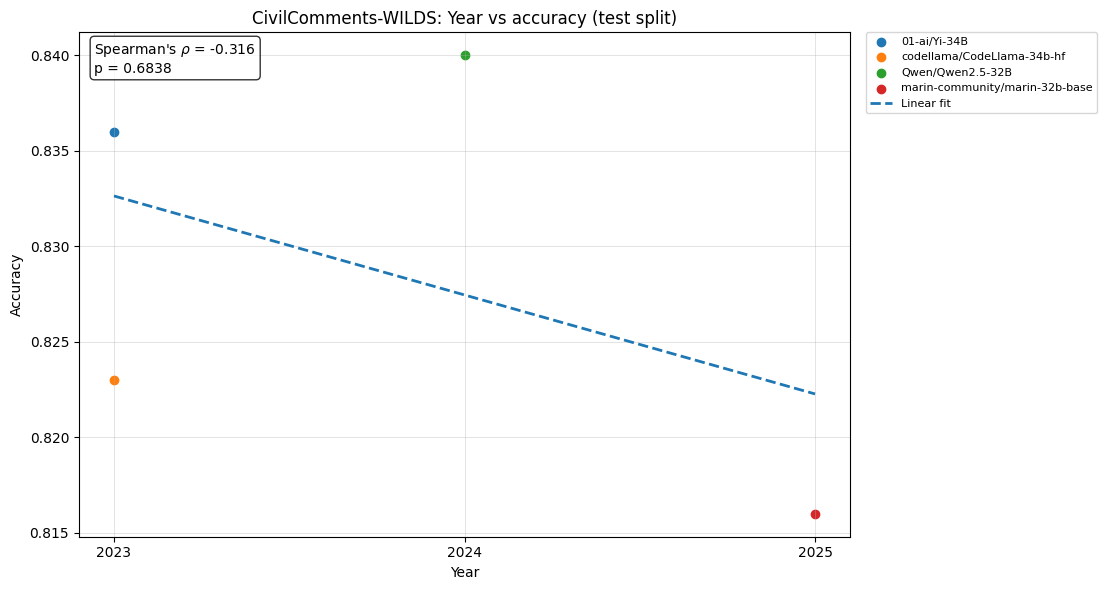

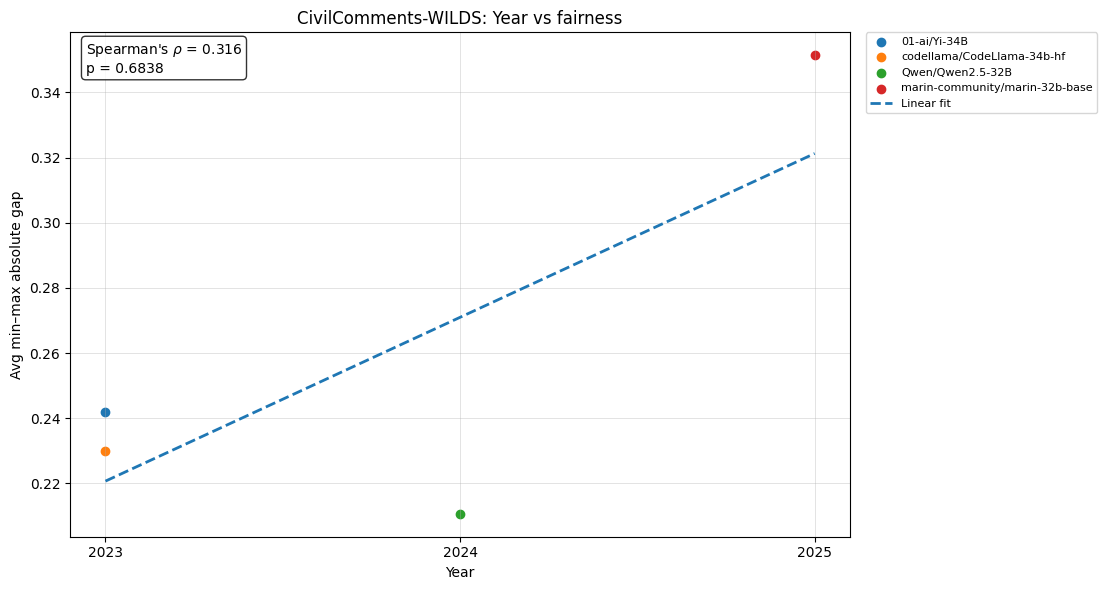

In [6]:
scatter_models_legend(df, "year", "test_acc",
                      "CivilComments-WILDS: Year vs accuracy (test split)",
                      "Year", "Accuracy",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

scatter_models_legend(df, "year", FAIR_ABS,
                      "CivilComments-WILDS: Year vs fairness", # (avg min–max absolute gap)
                      "Year", "Avg min–max absolute gap",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

# scatter_models_legend(df, "year", FAIR_VAR,
#                       "Year vs fairness (avg variance across groups, lower = more fair)",
#                       "Year", "Avg variance",
#                       x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

# scatter_models_legend(df, "test_acc", FAIR_ABS,
#                       "Accuracy vs fairness (avg min–max absolute gap)",
#                       "Accuracy", "Avg min–max absolute gap",
#                       x_is_year=False)

# scatter_models_legend(df, "test_acc", FAIR_VAR,
#                       "Accuracy vs fairness (avg variance)",
#                       "Accuracy", "Avg variance",
#                       x_is_year=False)

In [7]:
# compact tables
perf_cols = ["year","model_id","threshold_t","test_acc","test_pos_rate","test_fpr","test_fnr"]
fair_cols = ["year","model_id",
             "acc_minmax_abs","acc_minmax_rel","acc_var",
             "pos_rate_minmax_abs","pos_rate_minmax_rel","pos_rate_var",
             "fpr_minmax_abs","fpr_minmax_rel","fpr_var",
             "fnr_minmax_abs","fnr_minmax_rel","fnr_var",
             "avg_minmax_abs","avg_minmax_rel","avg_var"]

perf_tbl = df_sum[perf_cols].copy().sort_values(["year","model_id"])
fair_tbl = df_sum[fair_cols].copy().sort_values(["year","model_id"])

perf_tbl, fair_tbl

(   year                        model_id  threshold_t  test_acc  test_pos_rate  \
 0  2023                    01-ai/Yi-34B     0.858719     0.836          0.107   
 1  2023      codellama/CodeLlama-34b-hf     0.684264     0.823          0.102   
 2  2024                Qwen/Qwen2.5-32B     0.631803     0.840          0.113   
 3  2025  marin-community/marin-32b-base     0.549863     0.816          0.135   
 4  2025       tiiuae/Falcon-H1-34B-Base          NaN     0.879          0.000   
 
    test_fpr  test_fnr  
 0  0.085324  0.735537  
 1  0.089875  0.809917  
 2  0.086462  0.694215  
 3  0.112628  0.702479  
 4  0.000000  1.000000  ,
    year                        model_id  acc_minmax_abs  acc_minmax_rel  \
 0  2023                    01-ai/Yi-34B        0.254167        0.345382   
 1  2023      codellama/CodeLlama-34b-hf        0.369565        0.513852   
 2  2024                Qwen/Qwen2.5-32B        0.289565        0.399849   
 3  2025  marin-community/marin-32b-base        0.3

# bias

In [8]:
if "crows_bias" in df.columns:
    df = df.drop(columns=["crows_bias"])

BIAS_CSV = os.path.join(OUT_DIR, "bias_crows_pairs.csv")
df_bias = pd.read_csv(BIAS_CSV).sort_values(["year", "model_id"]).reset_index(drop=True)

df["year"] = df["year"].astype(int)
df["model_id"] = df["model_id"].astype(str)
df_bias["year"] = df_bias["year"].astype(int)
df_bias["model_id"] = df_bias["model_id"].astype(str)

df = df.merge(df_bias[["year", "model_id", "crows_bias"]], on=["year", "model_id"], how="left")

BAD_MODEL_ID = "Qwen/QwQ-32B-Preview" # need to remove this as it didnt finish running because of out of memeory error
df = df[df["model_id"] != BAD_MODEL_ID].copy().reset_index(drop=True)

print("Missing bias rows:", df["crows_bias"].isna().sum(), "/", len(df))
df[["year", "model_id", "test_acc", "crows_bias"]].head()


Missing bias rows: 0 / 4


,year,model_id,test_acc,crows_bias
0,2023,01-ai/Yi-34B,0.836,64.522546
1,2023,codellama/CodeLlama-34b-hf,0.823,62.267905
2,2024,Qwen/Qwen2.5-32B,0.840,56.830239
3,2025,marin-community/marin-32b-base,0.816,58.753316


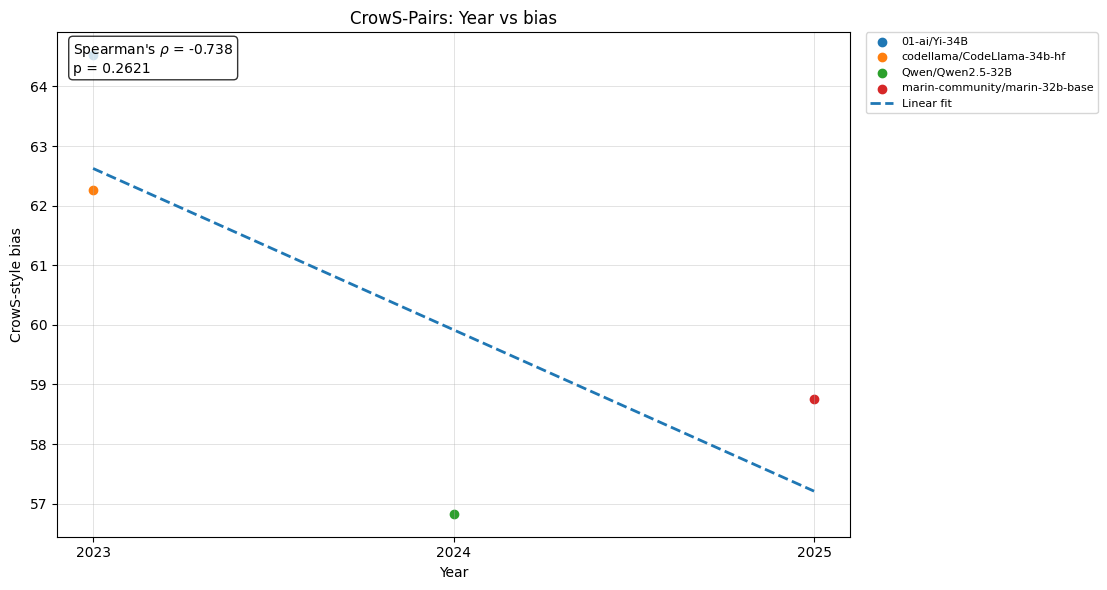

In [ ]:
# year vs bias
scatter_models_legend(df, "year", "crows_bias",
                      "CrowS-Pairs: Year vs bias", # (higher = more stereotypical preference)
                      "Year", "CrowS-style bias",
                      x_is_year=True, add_line=True, line_type="fit", corr_method="spearman", show_stats=True, stats_loc="inside")

average for each year

In [ ]:
# helper functions
def bootstrap_mean_ci(x, n_boot=5000, ci=95, seed=42):
    """
    Bootstrap CI for the mean of a 1D array.
    Returns mean, ci_low, ci_high, n, std.
    """
    x = np.asarray(x, dtype=float)
    x = x[~np.isnan(x)]
    n = len(x)

    if n == 0:
        return pd.Series({
            "n": 0,
            "mean": np.nan,
            "std": np.nan,
            "ci_low": np.nan,
            "ci_high": np.nan
        })

    mean = float(np.mean(x))
    std = float(np.std(x, ddof=1)) if n > 1 else 0.0

    # if only one model in a year, CI is just the point itself
    if n == 1:
        ci_low = mean
        ci_high = mean
    else:
        rng = np.random.default_rng(seed)
        boot_means = np.empty(n_boot, dtype=float)

        for b in range(n_boot):
            sample = rng.choice(x, size=n, replace=True)
            boot_means[b] = sample.mean()

        alpha = (100 - ci) / 2
        ci_low, ci_high = np.percentile(boot_means, [alpha, 100 - alpha])

    return pd.Series({
        "n": n,
        "mean": mean,
        "std": std,
        "ci_low": float(ci_low),
        "ci_high": float(ci_high)
    })


def summarize_by_year(df, value_col, n_boot=5000, ci=95, seed=42):
    rows = []

    for year, sub in df.groupby("year"):
        stats = bootstrap_mean_ci(sub[value_col].to_numpy(), n_boot=n_boot, ci=ci, seed=seed)
        rows.append({
            "year": int(year),
            "n": stats["n"],
            "mean": stats["mean"],
            "std": stats["std"],
            "ci_low": stats["ci_low"],
            "ci_high": stats["ci_high"],
        })

    return pd.DataFrame(rows).sort_values("year").reset_index(drop=True)


def plot_year_mean_ci(summary_df, title, ylabel):
    """
    Plot yearly mean with CI error bars.
    """
    x = summary_df["year"].astype(int).to_numpy()
    y = summary_df["mean"].astype(float).to_numpy()
    low = summary_df["ci_low"].astype(float).to_numpy()
    high = summary_df["ci_high"].astype(float).to_numpy()

    yerr = np.vstack([y - low, high - y])

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.errorbar(x, y, yerr=yerr, fmt="o-", capsize=4, color="deeppink", ecolor="deepskyblue")

    ax.set_title(title)
    ax.set_xlabel("Year")
    ax.set_ylabel(ylabel)
    ax.set_xticks(sorted(summary_df["year"].unique()))
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, linewidth=0.5, alpha=0.5)

    plt.tight_layout()
    plt.show()

In [11]:
# build year-level summaries
year_acc = summarize_by_year(df, "test_acc", n_boot=5000, ci=95, seed=42)
year_fair = summarize_by_year(df, FAIR_ABS, n_boot=5000, ci=95, seed=42)
year_bias = summarize_by_year(df, "crows_bias", n_boot=5000, ci=95, seed=42)

print("Year-level mean accuracy")
display(year_acc.round(4))

print("Year-level mean fairness")
display(year_fair.round(4))

print("Year-level mean bias")
display(year_bias.round(4))

Year-level mean accuracy


,year,n,mean,std,ci_low,ci_high
0,2023,2.0,0.8295,0.0092,0.823,0.836
1,2024,1.0,0.8400,0.0000,0.840,0.840
2,2025,1.0,0.8160,0.0000,0.816,0.816


Year-level mean fairness


,year,n,mean,std,ci_low,ci_high
0,2023,2.0,0.2358,0.0085,0.2298,0.2418
1,2024,1.0,0.2107,0.0000,0.2107,0.2107
2,2025,1.0,0.3514,0.0000,0.3514,0.3514


Year-level mean bias


,year,n,mean,std,ci_low,ci_high
0,2023,2.0,63.3952,1.5943,62.2679,64.5225
1,2024,1.0,56.8302,0.0000,56.8302,56.8302
2,2025,1.0,58.7533,0.0000,58.7533,58.7533
